In [1]:
print("Customer Segmentation ML Project")
print("VS Code Jupyter is working!")

Customer Segmentation ML Project
VS Code Jupyter is working!


In [ ]:
import pandas as pd

file_path = "../data/raw/Online Retail.xlsx"

# Test reading only 10 rows
test_df = pd.read_excel(
    file_path,
    engine="openpyxl",
    nrows=10
)

print("Excel file can be read successfully!")
print("Test rows:", test_df.shape[0])
print("Columns:", test_df.shape[1])
print("\nColumn names:")
print(test_df.columns.tolist())

print("\nFirst 10 rows:")
display(test_df)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import sklearn
import plotly
import openpyxl
import streamlit

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Plotly:", plotly.__version__)
print("OpenPyXL:", openpyxl.__version__)
print("Streamlit:", streamlit.__version__)

print("\nAll ML libraries are working!")

Pandas: 3.0.5
NumPy: 2.5.3
Matplotlib: 3.11.2
Seaborn: 0.13.2
Scikit-learn: 1.9.1
Plotly: 7.0.0
OpenPyXL: 3.1.5
Streamlit: 1.63.0

All ML libraries are working!


In [1]:
import pandas as pd

file_path = "../data/raw/Online Retail.xlsx"

df = pd.read_excel(
    file_path,
    engine="openpyxl"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (541909, 8)


In [2]:
print("Column names:")
print(df.columns.tolist())

print("\nFirst 10 transactions:")
display(df.head(10))

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 10 transactions:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [3]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [5]:
print("Numerical data summary:")
display(df[["Quantity", "UnitPrice"]].describe())

Numerical data summary:


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [6]:
negative_quantity = df[df["Quantity"] < 0]

print("Rows with negative Quantity:", len(negative_quantity))
print("Percentage:", round(len(negative_quantity) / len(df) * 100, 2), "%")

display(
    negative_quantity[
        ["InvoiceNo", "Description", "Quantity", "UnitPrice", "CustomerID", "Country"]
    ].head(10)
)

Rows with negative Quantity: 10624
Percentage: 1.96 %


,InvoiceNo,Description,Quantity,UnitPrice,CustomerID,Country
141,C536379,Discount,-1,27.50,14527.0,United Kingdom
154,C536383,SET OF 3 COLOURED FLYING DUCKS,-1,4.65,15311.0,United Kingdom
235,C536391,PLASTERS IN TIN CIRCUS PARADE,-12,1.65,17548.0,United Kingdom
236,C536391,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29,17548.0,United Kingdom
237,C536391,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29,17548.0,United Kingdom
238,C536391,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29,17548.0,United Kingdom
239,C536391,CHICK GREY HOT WATER BOTTLE,-12,3.45,17548.0,United Kingdom
240,C536391,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65,17548.0,United Kingdom
241,C536391,PLASTERS IN TIN SKULLS,-24,1.65,17548.0,United Kingdom
939,C536506,JAM MAKING SET WITH JARS,-6,4.25,17897.0,United Kingdom


In [7]:
cancelled_invoices = df["InvoiceNo"].astype(str).str.startswith("C")

print("Invoices starting with C:", cancelled_invoices.sum())
print(
    "Negative quantities with C invoice:",
    ((df["Quantity"] < 0) & cancelled_invoices).sum()
)

print(
    "Negative quantities without C invoice:",
    ((df["Quantity"] < 0) & ~cancelled_invoices).sum()
)

Invoices starting with C: 9288
Negative quantities with C invoice: 9288
Negative quantities without C invoice: 1336


In [8]:
negative_without_c = df[
    (df["Quantity"] < 0) & ~cancelled_invoices
]

print("Negative quantity without C:", len(negative_without_c))

display(
    negative_without_c[
        ["InvoiceNo", "Description", "Quantity", "UnitPrice", "CustomerID", "Country"]
    ].head(20)
)

Negative quantity without C: 1336


,InvoiceNo,Description,Quantity,UnitPrice,CustomerID,Country
2406,536589,NaN,-10,0.0,NaN,United Kingdom
4347,536764,NaN,-38,0.0,NaN,United Kingdom
7188,536996,NaN,-20,0.0,NaN,United Kingdom
7189,536997,NaN,-20,0.0,NaN,United Kingdom
7190,536998,NaN,-6,0.0,NaN,United Kingdom
7192,537000,NaN,-22,0.0,NaN,United Kingdom
7193,537001,NaN,-6,0.0,NaN,United Kingdom
7195,537003,NaN,-2,0.0,NaN,United Kingdom
7196,537004,NaN,-30,0.0,NaN,United Kingdom
7197,537005,NaN,-70,0.0,NaN,United Kingdom


In [9]:
print("Unique customers:", df["CustomerID"].nunique())
print("Rows with CustomerID:", df["CustomerID"].notna().sum())
print("Rows without CustomerID:", df["CustomerID"].isna().sum())


Unique customers: 4372
Rows with CustomerID: 406829
Rows without CustomerID: 135080


In [10]:
# Create a copy so the original dataset remains unchanged
clean_df = df.copy()

# 1. Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# 2. Remove rows without CustomerID
clean_df = clean_df.dropna(subset=["CustomerID"])

# 3. Keep only positive quantities
clean_df = clean_df[clean_df["Quantity"] > 0]

# 4. Keep only positive prices
clean_df = clean_df[clean_df["UnitPrice"] > 0]

print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))
print("Unique customers:", clean_df["CustomerID"].nunique())

Original rows: 541909
Cleaned rows: 392692
Rows removed: 149217
Unique customers: 4338


In [11]:
output_path = "../data/processed/cleaned_online_retail.csv"

clean_df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print("File:", output_path)

Cleaned dataset saved successfully!
File: ../data/processed/cleaned_online_retail.csv


In [12]:
import os

print("File exists:", os.path.exists(output_path))

File exists: True


In [2]:
import pandas as pd

# Load the cleaned transaction dataset
cleaned_path = "../data/processed/cleaned_online_retail.csv"

clean_df = pd.read_csv(cleaned_path)

print("Cleaned dataset loaded successfully!")
print("Shape:", clean_df.shape)
print("Unique customers:", clean_df["CustomerID"].nunique())

Cleaned dataset loaded successfully!
Shape: (392692, 8)
Unique customers: 4338


In [3]:
# Calculate revenue for each transaction
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]

print("Revenue feature created successfully!")
print(clean_df[["Quantity", "UnitPrice", "Revenue"]].head(10))

Revenue feature created successfully!
   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34
5         2       7.65    15.30
6         6       4.25    25.50
7         6       1.85    11.10
8         6       1.85    11.10
9        32       1.69    54.08


In [4]:
# Create customer-level features

customer_features = clean_df.groupby("CustomerID").agg(
    TotalSpend=("Revenue", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumTransactions=("InvoiceNo", "count"),
    NumOrders=("InvoiceNo", "nunique"),
    NumUniqueProducts=("StockCode", "nunique")
).reset_index()

print("Customer-level features created!")
print("Shape:", customer_features.shape)

display(customer_features.head(10))

Customer-level features created!
Shape: (4338, 6)


,CustomerID,TotalSpend,TotalQuantity,NumTransactions,NumOrders,NumUniqueProducts
0,12346.0,77183.60,74215,1,1,1
1,12347.0,4310.00,2458,182,7,103
2,12348.0,1797.24,2341,31,4,22
3,12349.0,1757.55,631,73,1,73
4,12350.0,334.40,197,17,1,17
5,12352.0,2506.04,536,85,8,59
6,12353.0,89.00,20,4,1,4
7,12354.0,1079.40,530,58,1,58
8,12355.0,459.40,240,13,1,13
9,12356.0,2811.43,1591,59,3,53


In [5]:
print("Customer feature summary:")
display(customer_features.describe())

print("\nMissing values:")
print(customer_features.isnull().sum())

print("\nCustomer feature columns:")
print(customer_features.columns.tolist())

Customer feature summary:


,CustomerID,TotalSpend,TotalQuantity,NumTransactions,NumOrders,NumUniqueProducts
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,2048.688081,1187.644537,90.523744,4.272015,61.501153
std,1721.808492,8985.230220,5043.619654,225.506968,7.697998,85.366768
min,12346.000000,3.750000,1.000000,1.000000,1.000000,1.000000
25%,13813.250000,306.482500,159.000000,17.000000,1.000000,16.000000
50%,15299.500000,668.570000,378.000000,41.000000,2.000000,35.000000
75%,16778.750000,1660.597500,989.750000,98.000000,5.000000,77.000000
max,18287.000000,280206.020000,196915.000000,7676.000000,209.000000,1787.000000



Missing values:
CustomerID           0
TotalSpend           0
TotalQuantity        0
NumTransactions      0
NumOrders            0
NumUniqueProducts    0
dtype: int64

Customer feature columns:
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumTransactions', 'NumOrders', 'NumUniqueProducts']


In [6]:
# Save customer-level features

customer_features_path = "../data/processed/customer_features.csv"

customer_features.to_csv(
    customer_features_path,
    index=False
)

print("Customer features saved successfully!")
print("File:", customer_features_path)
print("Rows:", len(customer_features))
print("Columns:", len(customer_features.columns))

Customer features saved successfully!
File: ../data/processed/customer_features.csv
Rows: 4338
Columns: 6


In [1]:
import pandas as pd

customer_features_path = "../data/processed/customer_features.csv"

customer_features = pd.read_csv(customer_features_path)

print("Customer features loaded successfully!")
print("Shape:", customer_features.shape)
print("Unique customers:", customer_features["CustomerID"].nunique())

Customer features loaded successfully!
Shape: (4338, 6)
Unique customers: 4338


In [2]:
customer_features.describe()

,CustomerID,TotalSpend,TotalQuantity,NumTransactions,NumOrders,NumUniqueProducts
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,2048.688081,1187.644537,90.523744,4.272015,61.501153
std,1721.808492,8985.230220,5043.619654,225.506968,7.697998,85.366768
min,12346.000000,3.750000,1.000000,1.000000,1.000000,1.000000
25%,13813.250000,306.482500,159.000000,17.000000,1.000000,16.000000
50%,15299.500000,668.570000,378.000000,41.000000,2.000000,35.000000
75%,16778.750000,1660.597500,989.750000,98.000000,5.000000,77.000000
max,18287.000000,280206.020000,196915.000000,7676.000000,209.000000,1787.000000


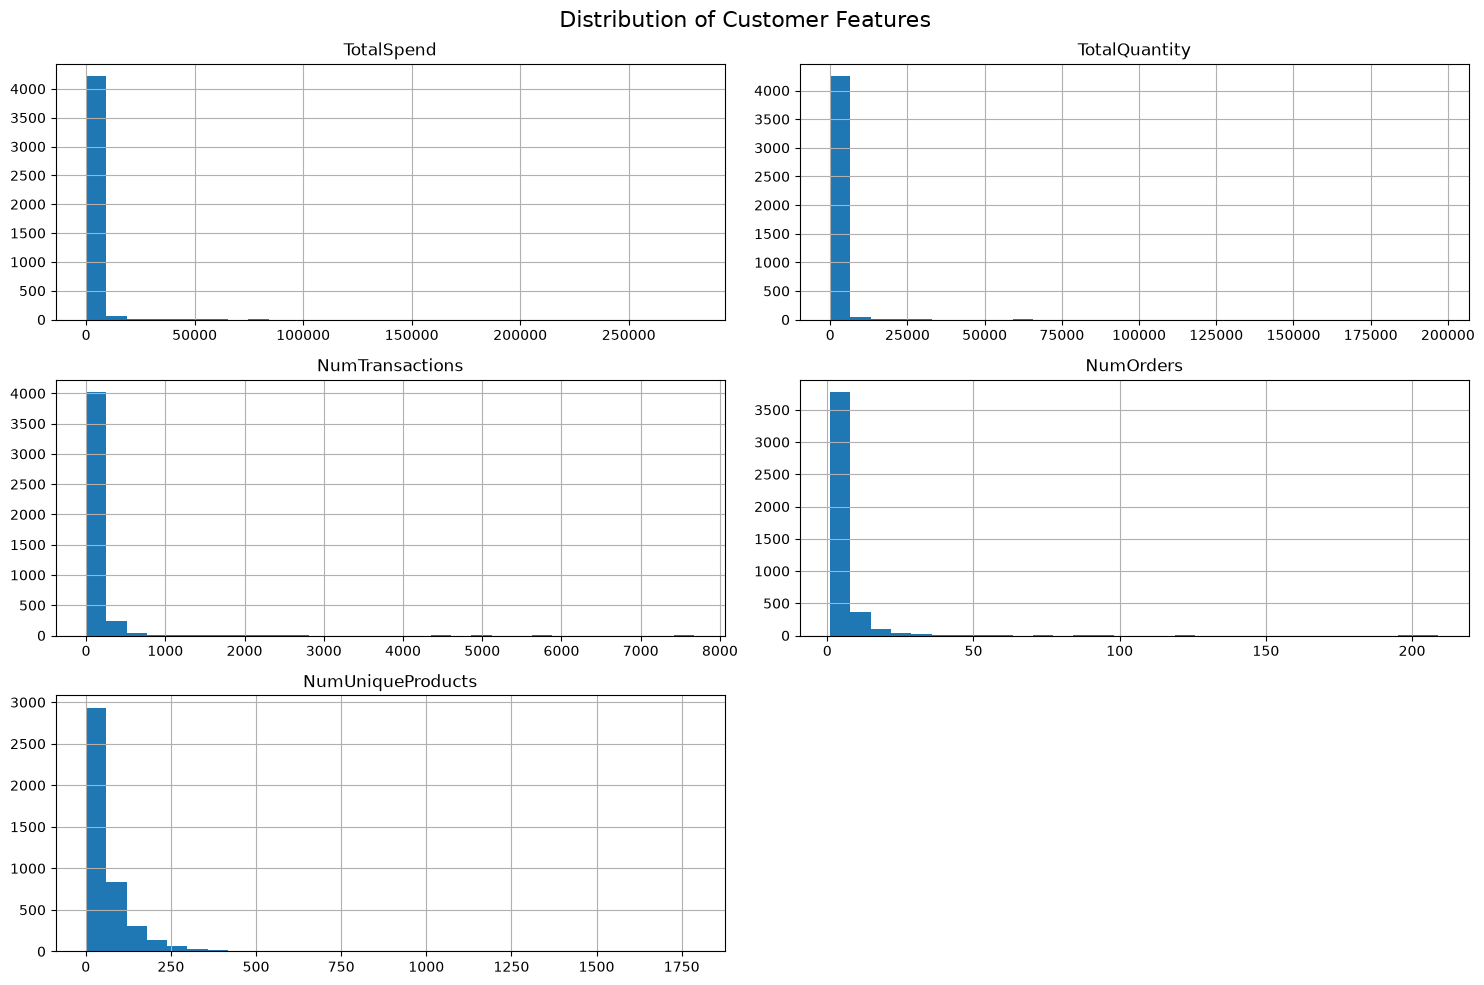

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = [
    "TotalSpend",
    "TotalQuantity",
    "NumTransactions",
    "NumOrders",
    "NumUniqueProducts"
]

customer_features[numeric_features].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle("Distribution of Customer Features", fontsize=16)
plt.tight_layout()
plt.show()

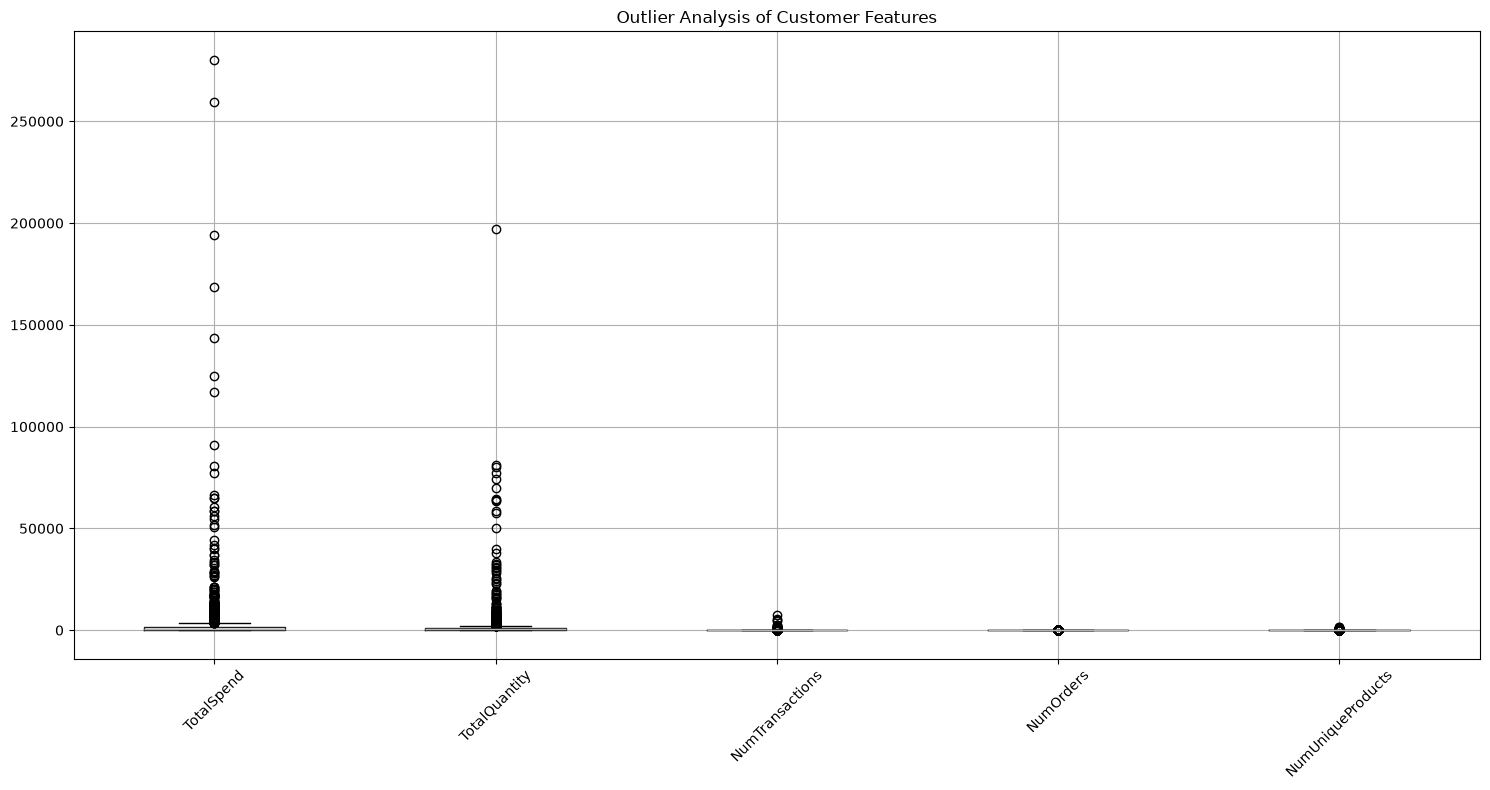

In [4]:
customer_features[numeric_features].boxplot(
    figsize=(15, 8)
)

plt.title("Outlier Analysis of Customer Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
top_customers = customer_features.sort_values(
    by="TotalSpend",
    ascending=False
).head(10)

top_customers

,CustomerID,TotalSpend,TotalQuantity,NumTransactions,NumOrders,NumUniqueProducts
1689,14646.0,280206.02,196915,2076,73,700
4201,18102.0,259657.30,64124,431,60,150
3728,17450.0,194390.79,69973,336,46,124
3008,16446.0,168472.50,80997,3,2,3
1879,14911.0,143711.17,80240,5670,201,1787
55,12415.0,124914.53,77374,714,21,444
1333,14156.0,117210.08,57768,1395,55,714
3771,17511.0,91062.38,64549,963,31,453
2702,16029.0,80850.84,40108,241,63,44
0,12346.0,77183.60,74215,1,1,1


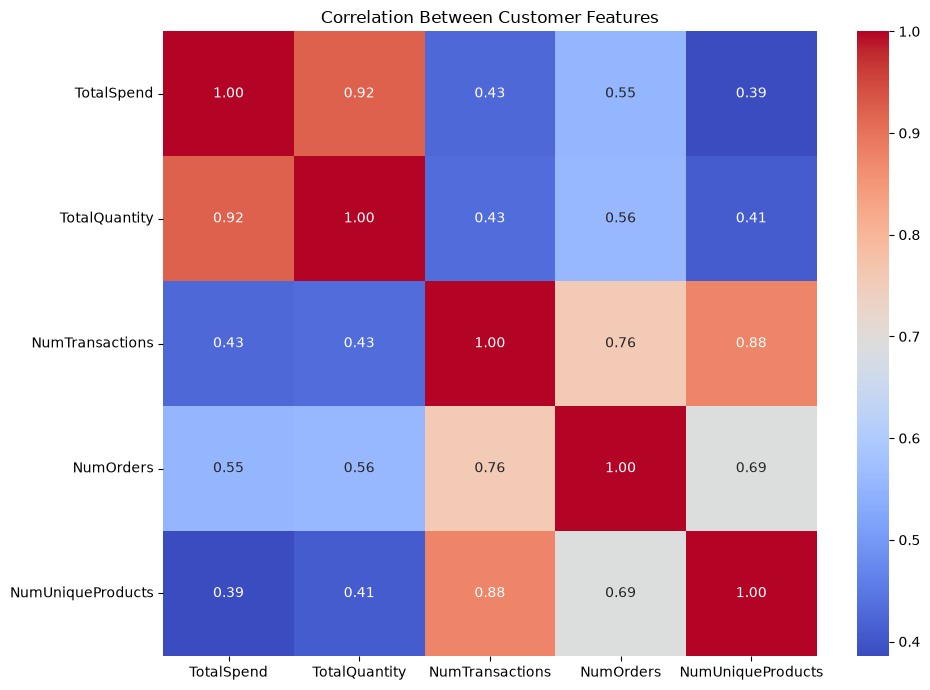

In [6]:
correlation_matrix = customer_features[numeric_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Customer Features")
plt.tight_layout()
plt.show()

In [7]:
print("EDA BUSINESS OBSERVATIONS")
print("=" * 40)

print("1. Total customers:", customer_features["CustomerID"].nunique())

print(
    "2. Average customer spend:",
    round(customer_features["TotalSpend"].mean(), 2)
)

print(
    "3. Median customer spend:",
    round(customer_features["TotalSpend"].median(), 2)
)

print(
    "4. Maximum customer spend:",
    round(customer_features["TotalSpend"].max(), 2)
)

print(
    "5. Average number of orders:",
    round(customer_features["NumOrders"].mean(), 2)
)

print(
    "6. Maximum number of orders:",
    customer_features["NumOrders"].max()
)

print(
    "7. Average unique products purchased:",
    round(customer_features["NumUniqueProducts"].mean(), 2)
)

EDA BUSINESS OBSERVATIONS
1. Total customers: 4338
2. Average customer spend: 2048.69
3. Median customer spend: 668.57
4. Maximum customer spend: 280206.02
5. Average number of orders: 4.27
6. Maximum number of orders: 209
7. Average unique products purchased: 61.5


In [8]:
import pandas as pd

cleaned_path = "../data/processed/cleaned_online_retail.csv"

clean_df = pd.read_csv(
    cleaned_path,
    parse_dates=["InvoiceDate"]
)

print("Cleaned transaction data loaded successfully!")
print("Shape:", clean_df.shape)
print("Unique customers:", clean_df["CustomerID"].nunique())
print("Date range:", clean_df["InvoiceDate"].min(), "to", clean_df["InvoiceDate"].max())

Cleaned transaction data loaded successfully!
Shape: (392692, 8)
Unique customers: 4338
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [9]:
last_date = clean_df["InvoiceDate"].max()

print("Last transaction date:", last_date)

Last transaction date: 2011-12-09 12:50:00


In [10]:
reference_date = last_date + pd.Timedelta(days=1)

print("Reference date:", reference_date)

Reference date: 2011-12-10 12:50:00


In [11]:
customer_recency = clean_df.groupby("CustomerID").agg(
    LastPurchaseDate=("InvoiceDate", "max")
).reset_index()

customer_recency["Recency"] = (
    reference_date - customer_recency["LastPurchaseDate"]
).dt.days

customer_recency.head()

,CustomerID,LastPurchaseDate,Recency
0,12346.0,2011-01-18 10:01:00,326
1,12347.0,2011-12-07 15:52:00,2
2,12348.0,2011-09-25 13:13:00,75
3,12349.0,2011-11-21 09:51:00,19
4,12350.0,2011-02-02 16:01:00,310


In [12]:
customer_frequency = clean_df.groupby("CustomerID").agg(
    Frequency=("InvoiceNo", "nunique")
).reset_index()

customer_frequency.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [13]:
customer_monetary = clean_df.groupby("CustomerID").agg(
    Monetary=("Revenue", "sum")
).reset_index()

customer_monetary.head()

KeyError: "Label(s) ['Revenue'] do not exist"

In [14]:
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]

print("Revenue column created successfully!")
print(clean_df[["Quantity", "UnitPrice", "Revenue"]].head())

Revenue column created successfully!
   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


In [15]:
customer_monetary = clean_df.groupby("CustomerID").agg(
    Monetary=("Revenue", "sum")
).reset_index()

customer_monetary.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [16]:
rfm = customer_recency.merge(
    customer_frequency,
    on="CustomerID"
).merge(
    customer_monetary,
    on="CustomerID"
)

print("RFM table created successfully!")
print("Shape:", rfm.shape)

rfm.head()

RFM table created successfully!
Shape: (4338, 5)


,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary
0,12346.0,2011-01-18 10:01:00,326,1,77183.60
1,12347.0,2011-12-07 15:52:00,2,7,4310.00
2,12348.0,2011-09-25 13:13:00,75,4,1797.24
3,12349.0,2011-11-21 09:51:00,19,1,1757.55
4,12350.0,2011-02-02 16:01:00,310,1,334.40


In [17]:
print("Missing values:")
print(rfm.isnull().sum())

print("\nRFM statistics:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe())

Missing values:
CustomerID          0
LastPurchaseDate    0
Recency             0
Frequency           0
Monetary            0
dtype: int64

RFM statistics:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


In [18]:
rfm_path = "../data/processed/rfm.csv"

rfm.to_csv(rfm_path, index=False)

print("RFM dataset saved successfully!")
print("Saved to:", rfm_path)
print("Shape:", rfm.shape)

RFM dataset saved successfully!
Saved to: ../data/processed/rfm.csv
Shape: (4338, 5)


In [1]:
import pandas as pd

rfm_path = "../data/processed/rfm.csv"

rfm = pd.read_csv(rfm_path)

print("RFM dataset loaded successfully!")
print("Shape:", rfm.shape)
print("Columns:", rfm.columns.tolist())

RFM dataset loaded successfully!
Shape: (4338, 5)
Columns: ['CustomerID', 'LastPurchaseDate', 'Recency', 'Frequency', 'Monetary']


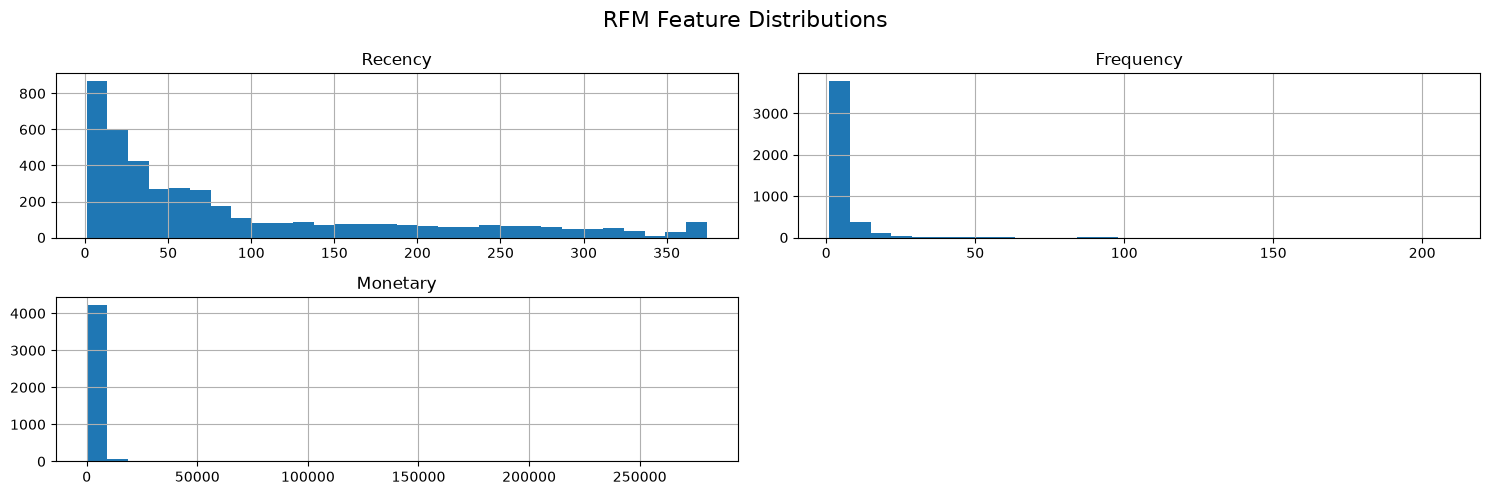

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

rfm_features = ["Recency", "Frequency", "Monetary"]

rfm[rfm_features].hist(
    figsize=(15, 5),
    bins=30
)

plt.suptitle("RFM Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [3]:
skewness = rfm[rfm_features].skew()

print("RFM Skewness:")
print(skewness)

RFM Skewness:
Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64


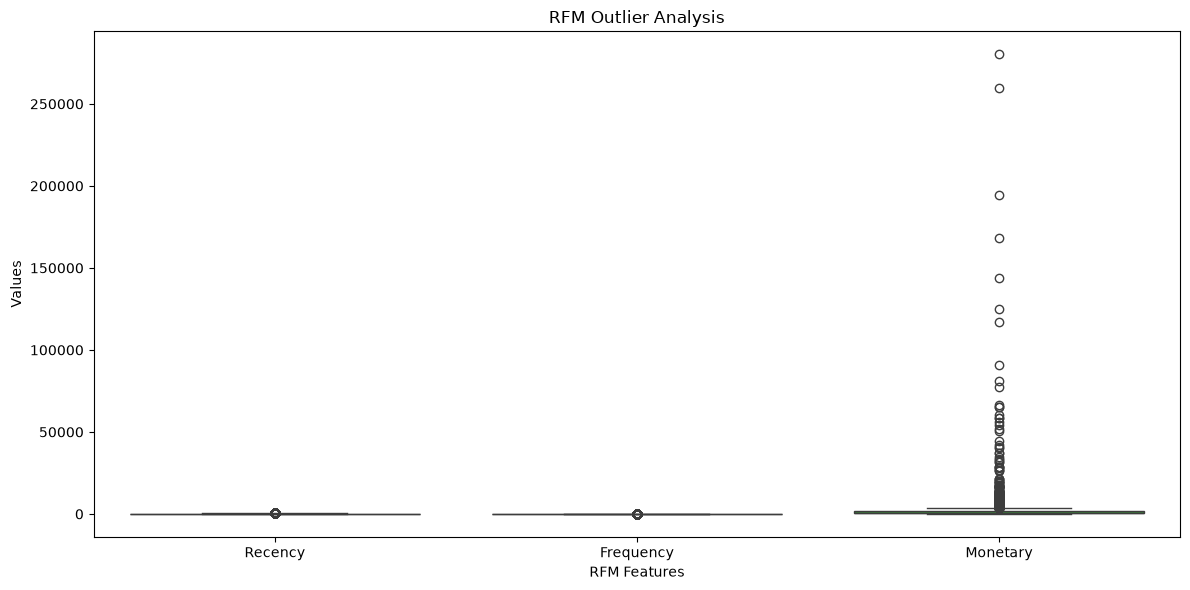

In [4]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=rfm[rfm_features])

plt.title("RFM Outlier Analysis")
plt.xlabel("RFM Features")
plt.ylabel("Values")

plt.tight_layout()
plt.show()

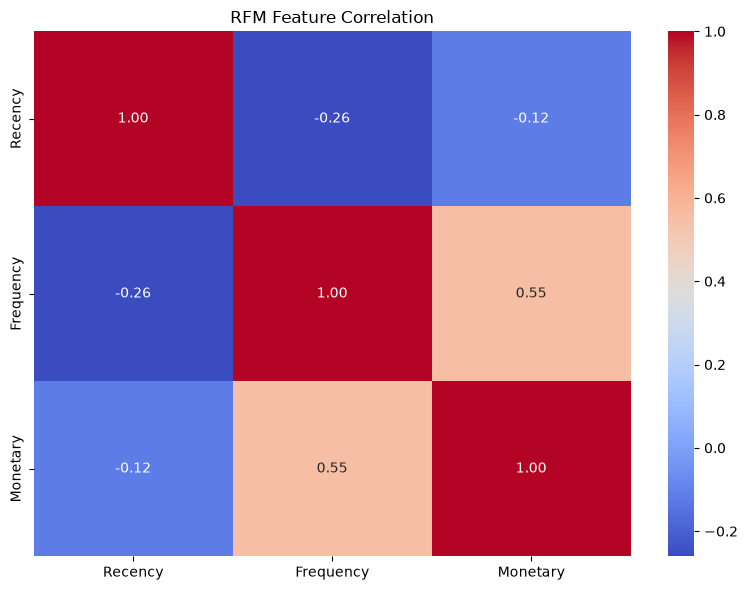

In [5]:
correlation_matrix = rfm[rfm_features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("RFM Feature Correlation")
plt.tight_layout()
plt.show()

In [6]:
rfm_summary = rfm[rfm_features].describe().T

rfm_summary

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.0000,51.00,142.0000,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.0000,2.00,5.0000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75,306.4825,668.57,1660.5975,280206.02


In [7]:
print("RFM BUSINESS SUMMARY")
print("=" * 40)

print("Total customers:", len(rfm))

print(
    "Average Recency:",
    round(rfm["Recency"].mean(), 2),
    "days"
)

print(
    "Median Recency:",
    round(rfm["Recency"].median(), 2),
    "days"
)

print(
    "Average Frequency:",
    round(rfm["Frequency"].mean(), 2),
    "orders"
)

print(
    "Median Frequency:",
    round(rfm["Frequency"].median(), 2),
    "orders"
)

print(
    "Average Monetary:",
    round(rfm["Monetary"].mean(), 2)
)

print(
    "Median Monetary:",
    round(rfm["Monetary"].median(), 2)
)

RFM BUSINESS SUMMARY
Total customers: 4338
Average Recency: 92.54 days
Median Recency: 51.0 days
Average Frequency: 4.27 orders
Median Frequency: 2.0 orders
Average Monetary: 2048.69
Median Monetary: 668.57


In [8]:
import pandas as pd

rfm_path = "../data/processed/rfm.csv"

rfm = pd.read_csv(rfm_path)

print("RFM dataset loaded successfully!")
print("Shape:", rfm.shape)
print("Columns:", rfm.columns.tolist())

RFM dataset loaded successfully!
Shape: (4338, 5)
Columns: ['CustomerID', 'LastPurchaseDate', 'Recency', 'Frequency', 'Monetary']


In [9]:
rfm_features = ["Recency", "Frequency", "Monetary"]

rfm_ml = rfm[rfm_features].copy()

print("ML feature dataset created!")
print("Shape:", rfm_ml.shape)
print("Features:", rfm_ml.columns.tolist())

rfm_ml.head()

ML feature dataset created!
Shape: (4338, 3)
Features: ['Recency', 'Frequency', 'Monetary']


,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


In [10]:
import numpy as np

print("Missing values:")
print(rfm_ml.isnull().sum())

print("\nInfinite values:")
print(np.isinf(rfm_ml).sum())

print("\nNegative values:")
print((rfm_ml < 0).sum())

Missing values:
Recency      0
Frequency    0
Monetary     0
dtype: int64

Infinite values:
Recency      0
Frequency    0
Monetary     0
dtype: int64

Negative values:
Recency      0
Frequency    0
Monetary     0
dtype: int64


In [11]:
skewness = rfm_ml.skew()

print("RFM Feature Skewness:")
print(skewness)

RFM Feature Skewness:
Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64


In [12]:
rfm_log = np.log1p(rfm_ml)

print("Log transformation completed!")

print("\nOriginal statistics:")
print(rfm_ml.describe())

print("\nLog-transformed statistics:")
print(rfm_log.describe())

Log transformation completed!

Original statistics:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000

Log-transformed statistics:
           Recency    Frequency     Monetary
count  4338.000000  4338.000000  4338.000000
mean      3.830734     1.345582     6.588562
std       1.340261     0.683104     1.258438
min       0.693147     0.693147     1.558145
25%       2.944439     0.693147     5.728418
50%       3.951244     1.098612     6.506636
75%       4.962845     1.791759     7.415535
max       5.926926     5.347108    12.543284


In [13]:
original_skewness = rfm_ml.skew()
transformed_skewness = rfm_log.skew()

skewness_comparison = pd.DataFrame({
    "Original Skewness": original_skewness,
    "Log-Transformed Skewness": transformed_skewness
})

skewness_comparison

,Original Skewness,Log-Transformed Skewness
Recency,1.246048,-0.379169
Frequency,12.067031,1.208652
Monetary,19.339368,0.396599


In [14]:
rfm_final = rfm_log.copy()

print("Final ML feature dataset created!")
print("Shape:", rfm_final.shape)
print("Columns:", rfm_final.columns.tolist())

rfm_final.head()

Final ML feature dataset created!
Shape: (4338, 3)
Columns: ['Recency', 'Frequency', 'Monetary']


,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [15]:
rfm_final_path = "../data/processed/rfm_features.csv"

rfm_final.to_csv(rfm_final_path, index=False)

print("Final RFM feature dataset saved!")
print("Path:", rfm_final_path)
print("Shape:", rfm_final.shape)

Final RFM feature dataset saved!
Path: ../data/processed/rfm_features.csv
Shape: (4338, 3)


In [1]:
import pandas as pd

features_path = "../data/processed/rfm_features.csv"

rfm_final = pd.read_csv(features_path)

print("RFM features loaded successfully!")
print("Shape:", rfm_final.shape)
print("Columns:", rfm_final.columns.tolist())

rfm_final.head()

RFM features loaded successfully!
Shape: (4338, 3)
Columns: ['Recency', 'Frequency', 'Monetary']


,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [2]:
import pandas as pd

features_path = "../data/processed/rfm_features.csv"

rfm_final = pd.read_csv(features_path)

print("RFM features loaded successfully!")
print("Shape:", rfm_final.shape)
print("Columns:", rfm_final.columns.tolist())

rfm_final.head()

RFM features loaded successfully!
Shape: (4338, 3)
Columns: ['Recency', 'Frequency', 'Monetary']


,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [3]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=rfm_final.columns
)

print("Scaled DataFrame created!")
print("Shape:", rfm_scaled_df.shape)

rfm_scaled_df.head()

NameError: name 'rfm_scaled' is not defined

In [4]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=rfm_final.columns
)

print("Scaled DataFrame created!")
print("Shape:", rfm_scaled_df.shape)

rfm_scaled_df.head()

NameError: name 'rfm_scaled' is not defined

In [5]:
print("Scaled feature means:")
print(rfm_scaled_df.mean())

print("\nScaled feature standard deviations:")
print(rfm_scaled_df.std())

Scaled feature means:


NameError: name 'rfm_scaled_df' is not defined

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_final)

print("Feature scaling completed!")
print("Shape:", rfm_scaled.shape)

Feature scaling completed!
Shape: (4338, 3)


In [7]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=rfm_final.columns
)

print("Scaled DataFrame created!")
print("Shape:", rfm_scaled_df.shape)

rfm_scaled_df.head()

Scaled DataFrame created!
Shape: (4338, 3)


,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


In [8]:
print("Scaled feature means:")
print(rfm_scaled_df.mean())

print("\nScaled feature standard deviations:")
print(rfm_scaled_df.std())

Scaled feature means:
Recency     -5.896620e-17
Frequency    3.439695e-17
Monetary    -3.537972e-16
dtype: float64

Scaled feature standard deviations:
Recency      1.000115
Frequency    1.000115
Monetary     1.000115
dtype: float64


In [9]:
scaled_path = "../data/processed/rfm_scaled.csv"

rfm_scaled_df.to_csv(scaled_path, index=False)

print("Scaled RFM dataset saved successfully!")
print("Path:", scaled_path)
print("Shape:", rfm_scaled_df.shape)

Scaled RFM dataset saved successfully!
Path: ../data/processed/rfm_scaled.csv
Shape: (4338, 3)


In [1]:
import pandas as pd

scaled_path = "../data/processed/rfm_scaled.csv"

rfm_scaled_df = pd.read_csv(scaled_path)

print("Scaled RFM dataset loaded successfully!")
print("Shape:", rfm_scaled_df.shape)
print("Columns:", rfm_scaled_df.columns.tolist())

rfm_scaled_df.head()

Scaled RFM dataset loaded successfully!
Shape: (4338, 3)
Columns: ['Recency', 'Frequency', 'Monetary']


,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled_df)
    inertia_values.append(kmeans.inertia_)

print("Elbow Method completed!")
print("Inertia values:", inertia_values)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

ImportError: DLL load failed while importing _base: An Application Control policy has blocked this file.

In [3]:
import sklearn

print("Scikit-learn version:", sklearn.__version__)
print("Scikit-learn location:", sklearn.__file__)

Scikit-learn version: 1.9.1
Scikit-learn location: c:\Users\vanshi\Desktop\cs\customer-segmentation-ml\.venv\Lib\site-packages\sklearn\__init__.py


In [4]:
import sklearn

print("Scikit-learn version:", sklearn.__version__)
print("Scikit-learn location:", sklearn.__file__)

Scikit-learn version: 1.9.1
Scikit-learn location: c:\Users\vanshi\Desktop\cs\customer-segmentation-ml\.venv\Lib\site-packages\sklearn\__init__.py


In [5]:
from sklearn.cluster import KMeans

print("KMeans imported successfully!")

ImportError: DLL load failed while importing _base: An Application Control policy has blocked this file.

In [6]:
import pandas as pd
import numpy as np
import sklearn

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("K-Means and Silhouette Score imported successfully!")

Pandas: 3.0.5
NumPy: 2.5.3
Scikit-learn: 1.9.1


ImportError: DLL load failed while importing _base: An Application Control policy has blocked this file.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

scaled_path = "../data/processed/rfm_scaled.csv"
rfm_scaled_df = pd.read_csv(scaled_path)

print("Dataset loaded successfully!")
print("Shape:", rfm_scaled_df.shape)
print("Columns:", rfm_scaled_df.columns.tolist())
print("Missing values:", rfm_scaled_df.isnull().sum().sum())
print("Infinite values:", np.isinf(rfm_scaled_df.to_numpy()).sum())

rfm_scaled_df.head()

Dataset loaded successfully!
Shape: (4338, 3)
Columns: ['Recency', 'Frequency', 'Monetary']
Missing values: 0
Infinite values: 0


,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


In [8]:
import numpy as np

def custom_kmeans(data, k, max_iterations=100, random_state=42):
    # Convert data into a NumPy array
    X = np.asarray(data, dtype=float)

    # Initialize cluster centers from randomly selected customers
    rng = np.random.default_rng(random_state)
    random_indices = rng.choice(len(X), size=k, replace=False)
    centroids = X[random_indices].copy()

    for iteration in range(max_iterations):
        # Calculate distance from each customer to each centroid
        distances = np.sqrt(
            ((X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2).sum(axis=2)
        )

        # Assign each customer to the nearest centroid
        labels = np.argmin(distances, axis=1)

        # Calculate updated centroids
        new_centroids = centroids.copy()

        for cluster in range(k):
            members = X[labels == cluster]

            if len(members) > 0:
                new_centroids[cluster] = members.mean(axis=0)

        # Stop when the centroids no longer change significantly
        if np.allclose(centroids, new_centroids, rtol=0, atol=1e-6):
            centroids = new_centroids
            break

        centroids = new_centroids

    # Reassign customers using the final centroids
    distances = np.sqrt(
        ((X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2).sum(axis=2)
    )
    labels = np.argmin(distances, axis=1)

    # Calculate inertia: sum of squared distances to assigned centroids
    inertia = np.sum((X - centroids[labels]) ** 2)

    return labels, centroids, inertia

In [9]:
labels, centroids, inertia = custom_kmeans(
    data=rfm_scaled_df,
    k=3,
    max_iterations=100,
    random_state=42
)

print("K-Means test completed successfully!")
print("Number of customers:", len(labels))
print("Number of cluster centers:", len(centroids))
print("Cluster centers:\n", centroids)
print("Inertia:", round(inertia, 2))

unique, counts = np.unique(labels, return_counts=True)

print("\nCustomers in each cluster:")
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} customers")

K-Means test completed successfully!
Number of customers: 4338
Number of cluster centers: 3
Cluster centers:
 [[-0.33552442  0.09983701  0.21820835]
 [-1.12686826  1.63495091  1.40699855]
 [ 0.76605434 -0.76084661 -0.77462598]]
Inertia: 4869.44

Customers in each cluster:
Cluster 0: 1697 customers
Cluster 1: 768 customers
Cluster 2: 1873 customers


In [10]:
k_values = range(2, 11)
inertia_values = []

for k in k_values:
    labels, centroids, inertia = custom_kmeans(
        data=rfm_scaled_df,
        k=k,
        max_iterations=100,
        random_state=42
    )

    inertia_values.append(inertia)
    print(f"K = {k}, Inertia = {inertia:.2f}")

print("\nElbow calculations completed!")

K = 2, Inertia = 6483.58
K = 3, Inertia = 4869.44
K = 4, Inertia = 3938.58
K = 5, Inertia = 3297.18
K = 6, Inertia = 2855.95
K = 7, Inertia = 2548.76
K = 8, Inertia = 2345.62
K = 9, Inertia = 2167.82
K = 10, Inertia = 2006.64

Elbow calculations completed!


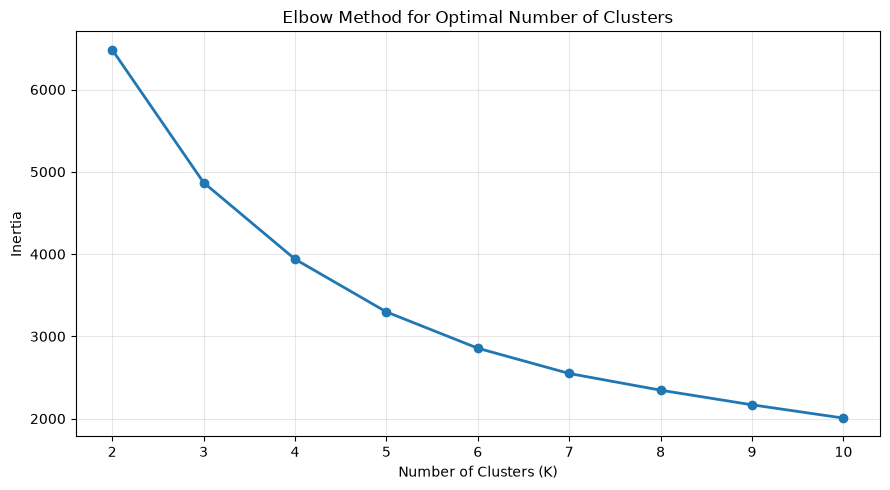

In [11]:
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
for k, inertia in zip(k_values, inertia_values):
    print(f"K = {k}: Inertia = {inertia:.2f}")

K = 2: Inertia = 6483.58
K = 3: Inertia = 4869.44
K = 4: Inertia = 3938.58
K = 5: Inertia = 3297.18
K = 6: Inertia = 2855.95
K = 7: Inertia = 2548.76
K = 8: Inertia = 2345.62
K = 9: Inertia = 2167.82
K = 10: Inertia = 2006.64


In [13]:
for k, inertia in zip(k_values, inertia_values):
    print(f"K = {k}: Inertia = {inertia:.2f}")

K = 2: Inertia = 6483.58
K = 3: Inertia = 4869.44
K = 4: Inertia = 3938.58
K = 5: Inertia = 3297.18
K = 6: Inertia = 2855.95
K = 7: Inertia = 2548.76
K = 8: Inertia = 2345.62
K = 9: Inertia = 2167.82
K = 10: Inertia = 2006.64


In [14]:
# Select a reproducible sample for silhouette evaluation
rng = np.random.default_rng(42)
X = rfm_scaled_df.to_numpy(dtype=float)

sample_size = min(500, len(X))
sample_indices = rng.choice(len(X), size=sample_size, replace=False)
X_sample = X[sample_indices]

def custom_silhouette_sample(X_sample, labels_sample):
    # Pairwise Euclidean distances among sampled customers
    distances = np.sqrt(
        np.sum(
            (X_sample[:, None, :] - X_sample[None, :, :]) ** 2,
            axis=2
        )
    )

    scores = []

    for i in range(len(X_sample)):
        own_cluster = labels_sample[i]
        own_mask = labels_sample == own_cluster
        own_mask[i] = False

        # Silhouette is undefined for a sample whose cluster has one member
        if not np.any(own_mask):
            scores.append(0.0)
            continue

        a = distances[i, own_mask].mean()

        other_means = []
        for cluster in np.unique(labels_sample):
            if cluster == own_cluster:
                continue

            other_mask = labels_sample == cluster
            if np.any(other_mask):
                other_means.append(distances[i, other_mask].mean())

        if not other_means:
            scores.append(0.0)
            continue

        b = min(other_means)
        denominator = max(a, b)
        scores.append((b - a) / denominator if denominator > 0 else 0.0)

    return float(np.mean(scores))


silhouette_scores = []

for k in range(2, 11):
    labels, centroids, inertia = custom_kmeans(
        data=X,
        k=k,
        max_iterations=100,
        random_state=42
    )

    sample_labels = labels[sample_indices]
    score = custom_silhouette_sample(X_sample, sample_labels)
    silhouette_scores.append(score)

    print(f"K = {k}: Approximate Silhouette Score = {score:.4f}")

print("\nSilhouette comparison completed!")

K = 2: Approximate Silhouette Score = 0.4324
K = 3: Approximate Silhouette Score = 0.3466
K = 4: Approximate Silhouette Score = 0.3465
K = 5: Approximate Silhouette Score = 0.3192
K = 6: Approximate Silhouette Score = 0.3046
K = 7: Approximate Silhouette Score = 0.3054
K = 8: Approximate Silhouette Score = 0.2773
K = 9: Approximate Silhouette Score = 0.2860
K = 10: Approximate Silhouette Score = 0.2765

Silhouette comparison completed!


In [15]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.4324
K = 3: Silhouette Score = 0.3466
K = 4: Silhouette Score = 0.3465
K = 5: Silhouette Score = 0.3192
K = 6: Silhouette Score = 0.3046
K = 7: Silhouette Score = 0.3054
K = 8: Silhouette Score = 0.2773
K = 9: Silhouette Score = 0.2860
K = 10: Silhouette Score = 0.2765


In [16]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.4324
K = 3: Silhouette Score = 0.3466
K = 4: Silhouette Score = 0.3465
K = 5: Silhouette Score = 0.3192
K = 6: Silhouette Score = 0.3046
K = 7: Silhouette Score = 0.3054
K = 8: Silhouette Score = 0.2773
K = 9: Silhouette Score = 0.2860
K = 10: Silhouette Score = 0.2765


In [17]:
# Select K based on the evaluation results
optimal_k = 2

# Fit the custom K-Means model
final_labels, final_centroids, final_inertia = custom_kmeans(
    data=rfm_scaled_df,
    k=optimal_k,
    max_iterations=100,
    random_state=42
)

# Add cluster assignments to the customer data
clustered_customers = rfm_scaled_df.copy()
clustered_customers["Cluster"] = final_labels

print("Selected K:", optimal_k)
print("Final inertia:", round(final_inertia, 2))
print("\nCustomer count per cluster:")
print(clustered_customers["Cluster"].value_counts().sort_index())

clustered_customers.head()

Selected K: 2
Final inertia: 6483.58

Customer count per cluster:
Cluster
0    2672
1    1666
Name: count, dtype: int64


,Recency,Frequency,Monetary,Cluster
0,1.461993,-0.955214,3.707716,1
1,-2.038734,1.074425,1.414903,1
2,0.373104,0.386304,0.720024,1
3,-0.623086,-0.955214,0.702287,0
4,1.424558,-0.955214,-0.614514,0


In [ ]:
# Validate the final cluster assignments
print("Total customers:", len(clustered_customers))
print("Missing cluster assignments:", clustered_customers["Cluster"].isna().sum())
print("Number of clusters:", clustered_customers["Cluster"].nunique())

print("\nCluster distribution:")
print(
    clustered_customers["Cluster"]
    .value_counts()
    .sort_index()
)

# Save cluster assignments
output_path = "../data/processed/customer_clusters_day9.csv"
clustered_customers.to_csv(output_path, index=False)

print("\nCluster assignments saved to:", output_path)